# London Airbnb Analysis — Predictive Modelling

This notebook builds two models:
1. **Regression** — predict the price of a listing based on its features
2. **Classification** — predict whether a listing is good value or overpriced

We use Scikit-learn for both models.

## 1. Import Libraries

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

In [26]:
# Load the cleaned listings data
listings = pd.read_csv('../data/listings_clean.csv')

print("Listings loaded!")
print("Rows:", len(listings))

Listings loaded!
Rows: 60951


## 3. Prepare Features for Regression

We select the columns that are most likely to predict price. We keep it simple with numeric columns only.

In [27]:
# Select the columns we want to use to predict price
features = [
    'accommodates',
    'beds',
    'bathrooms',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'availability_365'
]

# Our target variable is price
target = 'price'

print("Features selected:", features)

Features selected: ['accommodates', 'beds', 'bathrooms', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365']


In [28]:
# Keep only the columns we need
model_data = listings[features + [target]]

# Drop any rows with missing values
model_data = model_data.dropna()

print("Rows after dropping missing values:", len(model_data))

Rows after dropping missing values: 47584


In [29]:
# X is our features (inputs)
X = model_data[features]

# y is our target (what we want to predict)
y = model_data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (47584, 7)
y shape: (47584,)


## 4. Train the Regression Model

We split the data into training and test sets, train a linear regression model, then evaluate how well it predicts price.

In [30]:
# Split the data into training and test sets
# We use 80% to train the model and 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 38067
Test rows: 9517


In [31]:
# Create the linear regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [32]:
# Use the trained model to predict prices on the test set
y_pred = model.predict(X_test)

print("Predictions made!")
print("First 5 predicted prices:", y_pred[:5].round(2))
print("First 5 actual prices:", y_test[:5].values)

Predictions made!
First 5 predicted prices: [166.05  97.43  67.78  77.2  171.2 ]
First 5 actual prices: [175.  77.  58.  32. 203.]


In [33]:
# Check how accurate our predictions are

# Mean Absolute Error (MAE) = average difference between predicted and actual price
# Lower is better — a MAE of £50 means we are off by £50 on average
mae = mean_absolute_error(y_test, y_pred)

# R2 Score = how much of the price variation our model explains
# 1.0 = perfect, 0.0 = no better than guessing the average price
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error: £", round(mae, 2))
print("R2 Score:", round(r2, 2))
print("")
print("Our predictions are off by £", round(mae, 2), "on average")
print("The model explains", round(r2 * 100, 1), "% of the variation in price")

Mean Absolute Error: £ 68.56
R2 Score: 0.38

Our predictions are off by £ 68.56 on average
The model explains 37.9 % of the variation in price


## 5. Visualise Predictions

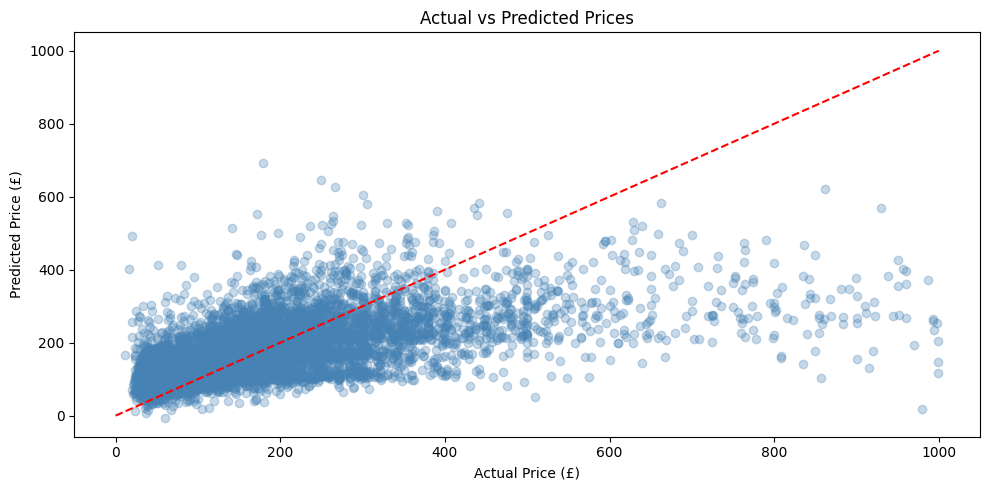

In [34]:
# Plot actual vs predicted prices
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([0, 1000], [0, 1000], color='red', linestyle='--')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.tight_layout()
plt.show()

In [35]:
# Show which features have the most impact on price
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
})

feature_importance = feature_importance.sort_values('coefficient', ascending=False)

print("Feature coefficients:")
print(feature_importance)

Feature coefficients:
                feature  coefficient
2             bathrooms    47.349833
0          accommodates    32.897080
5  review_scores_rating    14.877707
3        minimum_nights     0.141749
6      availability_365     0.040659
4     number_of_reviews    -0.123380
1                  beds    -9.461391


## 6. Classification Model — Good Value vs Overpriced

We classify listings as good value (high rating, low price) or overpriced (high price, low rating).

In [36]:
# Calculate the median price and median rating
median_price = listings['price'].median()
median_rating = listings['review_scores_rating'].median()

print("Median price: £", median_price)
print("Median rating:", median_rating)

Median price: £ 133.0
Median rating: 4.82


In [37]:
# A listing is good value if it is below median price AND above median rating
def label_listing(row):
    # Check if the price is at or below the median price
    price_is_low = row['price'] <= median_price
    
    # Check if the rating is at or above the median rating
    rating_is_high = row['review_scores_rating'] >= median_rating
    
    # Only label as good value if BOTH conditions are true
    if price_is_low and rating_is_high:
        return 'good value'
    else:
        return 'not good value'

# Apply the function to every row in the listings dataframe
listings['label'] = listings.apply(label_listing, axis=1)

print("Label counts:")
print(listings['label'].value_counts())

Label counts:
label
not good value    48974
good value        11977
Name: count, dtype: int64


In [38]:
# Prepare features for the classification model
# We use the same features as the regression model
class_data = listings[features + ['label']].dropna()

# Separate features and label
X_class = class_data[features]
y_class = class_data['label']

print("Rows:", len(class_data))
print("Label counts:")
print(y_class.value_counts())

Rows: 47584
Label counts:
label
not good value    35607
good value        11977
Name: count, dtype: int64


In [39]:
# Split into training and test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

print("Training rows:", len(X_train_c))
print("Test rows:", len(X_test_c))

Training rows: 38067
Test rows: 9517


In [40]:
# Import and train a logistic regression classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create and train the model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_c, y_train_c)

print("Classifier trained!")

Classifier trained!


In [41]:
# Make predictions on the test set
y_pred_c = classifier.predict(X_test_c)

# Check accuracy
accuracy = accuracy_score(y_test_c, y_pred_c)
print("Accuracy:", round(accuracy * 100, 1), "%")
print("")
print(classification_report(y_test_c, y_pred_c))

Accuracy: 87.7 %

                precision    recall  f1-score   support

    good value       0.77      0.73      0.75      2400
not good value       0.91      0.93      0.92      7117

      accuracy                           0.88      9517
     macro avg       0.84      0.83      0.83      9517
  weighted avg       0.88      0.88      0.88      9517



## 7. Summary

**Regression Model — Predicting Price:**
- Features used: accommodates, beds, bathrooms, minimum nights, number of reviews, review score, availability
- Mean Absolute Error: £68.56 — predictions are off by £68 on average
- R2 Score: 0.38 — the model explains 38% of price variation
- Most important feature: bathrooms (+£47 per bathroom)
- Second most important: accommodates (+£33 per extra guest)

**Classification Model — Good Value vs Not Good Value:**
- A listing is good value if price is below £133 AND rating is above 4.82
- Accuracy: 87.7%
- 11,977 listings (20%) classified as good value
- The model is better at identifying overpriced listings (91%) than good value ones (77%)

**Limitations:**
- Linear regression does not capture location which is a major price driver
- Adding neighbourhood as a feature would likely improve both models significantly

In [42]:
# Save the listings with labels
listings.to_csv('../data/listings_modelling.csv', index=False)

print("Saved!")

Saved!
